<div style="background-color: white; border: 2px solid black; border-radius: 20px; padding: 15px 25px; display: inline-block; color: black;">
<font face='Liberation serif' size=3>
    
#### **Привет!** 👋

---

Меня зовут Нелли.

Перед тем, как ты приступишь к проверке моей работы, хотела написать о самой моей большой боли в модуле с `git` и с установкой библиотеки `phik`. Дело в том, что еще во времена динозавров я именовала своего пользователя, используя кириллицу. И вот в связи с этим и еще не супер большой памятью на ноуте мне приходилось исполнять танцы с бубнами, чтобы как-то все заработало. В конечном итоге, мне не хотелось тратить много времени на это все, так как надо успеть сдать проект.

Чтобы выполнить последнее задание я воспользовалась тетрадкой, которая есть в уроке. У меня в локальной тетрадке библиотека phik устанавливается непосредственно перед самим заданием, чтобы работа кода не останавливалась из-за ошибки в самом начале.
    
Код рабочий - я проверяла в тетрадке Яндекс Практикума.
 
---
<a id="start"></a>

# Анализ лояльности пользователей Яндекс Афиши
- Автор: Ибрагимова Нелли
- Дата: 11.06.2026

## Цели и задачи проекта

**Цель:** Провести исследовательский анализ лояльности пользователей Яндекс Афиши, чтобы выявлять перспективных клиентов и предлагать им персонализированные условия, точно настраивать рекламу на аудитории с высокой вероятностью возврата, оптимизировать маркетинговые бюджеты, повысить общий уровень удержания клиентов.

**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:
    - сформировать профиль пользователя;
    - исследование признаков, влияющих на возврат пользователей;
    - изучить количественные характеристики заказов пользователей;
    - изучить временные параметры, связанные с первым заказом пользователей;
    - изучить, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок.
4. Сформулировать выводы по проведённому анализу.

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---

In [1]:
!pip install sqlalchemy

In [2]:
!pip install psycopg2-binary

In [3]:
import pandas as pd
from sqlalchemy import create_engine

In [4]:
# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
db_config = {'user': 'praktikum_student', # имя пользователя
             'pwd': 'Sdf4$2;d-d30pp', # пароль
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432, # порт подключения
             'db': 'data-analyst-afisha' # название базы данных
             }

In [6]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

In [7]:
engine = create_engine(connection_string)

In [8]:
query = '''
WITH set_config_precode AS (
  SELECT set_config('synchronize_seqscans', 'off', true)
)
SELECT
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    EXTRACT(DAY FROM (p.created_dt_msk - LAG(p.created_dt_msk) OVER (PARTITION BY p.user_id ORDER BY p.created_dt_msk)))::int AS days_since_prev,
    p.event_id,
    e.event_name_code AS event_name,
    e.event_type_main,
    p.service_name,
    r.region_name,
    c.city_name
FROM afisha.purchases AS p
LEFT JOIN afisha.events AS e ON p.event_id = e.event_id
LEFT JOIN afisha.city AS c ON e.city_id = c.city_id
LEFT JOIN afisha.regions AS r ON c.region_id = r.region_id
WHERE device_type_canonical IN ('mobile', 'desktop') AND e.event_type_main != 'фильм'
ORDER BY user_id;
'''

In [9]:
df = pd.read_sql_query(query, con=engine)

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [10]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

---
Датасет `df` содержит 15 столбцов и 290611 строк, в которых представлена информация о покупках билетов в разных регионах и от разных операторов.

Изучим типы данных и их корректность:
- **Числовые значения с плавающей запятой (float64).** Два столбца, `revenue`, `days_since_prev` содержат информацию о выручке от заказа и количестве дней от предыдущей покупки пользователя и представлены типом `float64`. Это верное решение для столбца `revenue`, так как они могут включать дробные значения, а `days_since_prev` включает целочисленные значения.
- **Строковые данные (object).** Восемь столбцов имеют тип данных `object`:
    - `user_id`, `device_type_canonical`, `currency_code`, `event_name`, `event_type_main`, `service_name`, `region_name` и `city_name` содержат строковую информацию (id пользователя, тип устройства, валюта оплаты, название мероприятия, основной тип мероприятия, название билетного оператора, название региона и название города), что логично для текстовых данных. Здесь тип данных `object` подходит.
- **Числовые целочисленные значения (int64).** Три столбца имеют тип данных `int` - `order_id`, `tickets_count` и `event_id`. Эти столбцы содержат информацию об id заказа, количестве купленных билетов и id мероприятия - они включают целочисленные значения.
- **Дата и время (datetime64).** Два столбца имеют тип данных `datetime64` - `order_dt` и `order_ts`. Содержат информацию о дате создания заказа и дате и времени создания заказа - подходящий тип данных для данных столбцов.


Пропуски содержатся в столбцах `days_since_prev`. Однако следует проверить и другие столбцы: в них могут встречаться значения-индикаторы, которые будут говорить об отсутствии данных.
Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---

Выгрузим датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год.

In [12]:
rates_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [13]:
rates_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [14]:
rates_df.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


---
Датасет `rates_df` содержит 4 столбца и 357 строк, в которых представлена информация о курсе казахстанского тенге по отношению к российскому рублю за 2024 год.

Изучим типы данных и их корректность:
- **Числовые значения с плавающей запятой (float64).** Один столбец - `curs` содержит информацию о курсе рубля для 100 тенге. Это верное решение, так как он включает дробные значения.
- **Строковые данные (object).** Два столбца имеют тип данных `object`:
    - `data` и `cdx` содержат строковую информацию (дата и наименование валюты), что логично для столбца `cdx`. А у столбца `data` лучше изменить тип данных на `datetime64`.
- **Числовые целочисленные значения (int64).** Один столбец имеет тип данных `int` - `nominal`. Этот столбец содержит информацию о номинале (100 тенге для всех строк) - он включает целочисленные значения.

---

Проведем преобразование типов данных.

In [15]:
rates_df['data'] = pd.to_datetime(rates_df['data'])

Создадим словарь дата - курс 1 тенге.

In [16]:
rate_dict = dict(
    zip(rates_df['data'],
        rates_df['curs'] / rates_df['nominal'])
)

Создадим столбец `revenue_rub` - выручка в рублях, которому передаем значения столбца `revenue`.

In [17]:
df['revenue_rub'] = df['revenue']

Создадим маску `mask`. Далее выполним преобразование тенге в рубли.

In [18]:
mask = df['currency_code'] == 'kzt'

df.loc[mask, 'revenue_rub'] = (round(
    df.loc[mask, 'revenue']
    * df.loc[mask, 'order_dt'].map(rate_dict), 2)
)

Для проверки корректного выполнения кода - выводим курс за определенную дату `2024-09-17` и первые 15 строк из датасета `df`. 

In [19]:
rates_df[rates_df['data'] == '2024-09-17'].head()

,data,nominal,curs,cdx
251,2024-09-17,100,19.0125,kzt


In [20]:
df[df['currency_code'] == 'kzt'].head(15)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
70,0033403583a55ed,mobile,7850214,2024-09-17,2024-09-17 16:52:06,kzt,518.10,4,20.0,559919,f5ec2467-ee48-42f3-89a0-a2d90d1d6fce,другое,Билеты без проблем,Верхоречная область,Серебрянка,98.50
89,0040e12d70fae81,desktop,8634925,2024-09-02,2024-09-02 19:49:14,kzt,347.18,3,39.0,559476,61ec7c0e-ea0c-4a3e-a63a-09cbe1bc6177,другое,Билеты без проблем,Верхоречная область,Серебрянка,65.73
96,0054b38b2653e6e,mobile,7625522,2024-09-09,2024-09-09 18:06:04,kzt,328.77,4,NaN,559582,524f434e-0381-4f47-9688-7c4e41961b65,другое,Билеты без проблем,Верхоречная область,Серебрянка,61.15
277,00f4f5244501ce6,mobile,720419,2024-06-11,2024-06-11 20:15:57,kzt,22021.55,5,NaN,536826,76af4f88-c554-4e9e-9df4-1cc8aeec8959,концерты,Мой билет,Верхоречная область,Серебрянка,4380.70
460,01370a0e9c1a7d5,desktop,5227657,2024-06-04,2024-06-04 13:28:17,kzt,7397.66,4,1.0,533803,0686ac7b-6f3e-4177-bb73-16b54acd1223,концерты,Мой билет,Шанырский регион,Широковка,1478.30
461,01370a0e9c1a7d5,mobile,2229811,2024-06-04,2024-06-04 13:19:47,kzt,7397.66,4,0.0,533803,0686ac7b-6f3e-4177-bb73-16b54acd1223,концерты,Мой билет,Шанырский регион,Широковка,1478.30
462,01370a0e9c1a7d5,mobile,2229782,2024-06-04,2024-06-04 13:17:35,kzt,3698.83,2,0.0,533803,0686ac7b-6f3e-4177-bb73-16b54acd1223,концерты,Мой билет,Шанырский регион,Широковка,739.15
463,01370a0e9c1a7d5,mobile,2229753,2024-06-04,2024-06-04 13:26:32,kzt,5548.24,3,0.0,533803,0686ac7b-6f3e-4177-bb73-16b54acd1223,концерты,Мой билет,Шанырский регион,Широковка,1108.72
464,01370a0e9c1a7d5,mobile,2229724,2024-06-04,2024-06-04 13:25:28,kzt,7397.66,4,0.0,533803,0686ac7b-6f3e-4177-bb73-16b54acd1223,концерты,Мой билет,Шанырский регион,Широковка,1478.30
515,01370a0e9c1a7d5,mobile,2044298,2024-09-05,2024-09-05 16:15:58,kzt,361.08,4,1.0,561747,27956246-d4a5-4b76-b5db-719831c41591,другое,Мой билет,Шанырский регион,Синеводск,66.52


---
Преобразования выполнены корректно.

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

Считаем количество пропусков в каждом столбце и их долю.

In [21]:
df.isna().sum().sort_values()

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
event_id                     0
event_name                   0
event_type_main              0
service_name                 0
region_name                  0
city_name                    0
revenue_rub                  0
days_since_prev          21933
dtype: int64

In [22]:
df.isna().sum().sort_values() / df.shape[0]

user_id                  0.000000
device_type_canonical    0.000000
order_id                 0.000000
order_dt                 0.000000
order_ts                 0.000000
currency_code            0.000000
revenue                  0.000000
tickets_count            0.000000
event_id                 0.000000
event_name               0.000000
event_type_main          0.000000
service_name             0.000000
region_name              0.000000
city_name                0.000000
revenue_rub              0.000000
days_since_prev          0.075472
dtype: float64

---
**Доля пропущенных значений:**
- 21933 пропуска в столбце `days_since_prev` — это почти 8% данных.

В столбцах `days_since_prev` причиной появления пропусков являются пользователи с одной покупкой, так как данный столбец содержит в себе информацию о количетве дней от предыдущей покупки.

С пропусками ничего делать не будем.

Оптимизируем числовые значения с плавающей точкой.

In [23]:
for column in ['revenue', 'days_since_prev', 'revenue_rub']:
    df[column] = pd.to_numeric(df[column], downcast='float')

In [24]:
# Проверим типы данных в датафрейме df
df.dtypes

user_id                          object
device_type_canonical            object
order_id                          int64
order_dt                 datetime64[ns]
order_ts                 datetime64[ns]
currency_code                    object
revenue                         float32
tickets_count                     int64
days_since_prev                 float32
event_id                          int64
event_name                       object
event_type_main                  object
service_name                     object
region_name                      object
city_name                        object
revenue_rub                     float32
dtype: object

---
Далее проверим, встречаются ли в данных значения-индикаторы, которые можно рассматривать как пропуски.

Посмотрим на уникальные значения в ключевых данных — среди них тип устройст, валюта оплаты, количество купленных билетов, основной тип мероприятия, название билетного оператора, название региона, название города.

In [25]:
for column in ['device_type_canonical', 'currency_code', 'tickets_count', 'event_type_main', 'service_name', 'region_name', 'city_name']:
    print(f'Уникальные значения в столбце {column}:')
    print(df[column].sort_values().unique())
    print()

Уникальные значения в столбце device_type_canonical:
['desktop' 'mobile']

Уникальные значения в столбце currency_code:
['kzt' 'rub']

Уникальные значения в столбце tickets_count:
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 17 19 27 30 37 47 57]

Уникальные значения в столбце event_type_main:
['выставки' 'другое' 'концерты' 'спорт' 'стендап' 'театр' 'ёлки']

Уникальные значения в столбце service_name:
['Crazy ticket!' 'Show_ticket' 'Билет по телефону' 'Билеты без проблем'
 'Билеты в интернете' 'Билеты в руки' 'Быстробилет' 'Быстрый кассир'
 'Весь в билетах' 'Восьмёрка' 'Вперёд!' 'Выступления.ру'
 'Городской дом культуры' 'Дом культуры' 'Дырокол' 'За билетом!'
 'Зе Бест!' 'КарандашРУ' 'Кино билет' 'Край билетов' 'Лимоны'
 'Лови билет!' 'Лучшие билеты' 'Мир касс' 'Мой билет' 'Облачко'
 'Прачечная' 'Радио ticket' 'Реестр' 'Росбилет' 'Тебе билет!' 'Телебилет'
 'Тех билет' 'Цвет и билет' 'Шоу начинается!' 'Яблоко']

Уникальные значения в столбце region_name:
['Белоярская область' 'Бересто

In [26]:
# Проверяем полные дубликаты в датафрейме df
df.duplicated().sum()

0

В датафрейме нет полных дубликатов.

---
Оценим статические показатели выручки.

In [27]:
df['revenue_rub'].describe()

count    290611.000000
mean        555.568237
std         875.455505
min         -90.760002
25%         113.970001
50%         351.140015
75%         802.049988
max       81174.539062
Name: revenue_rub, dtype: float64

Можно предположить, что данные выручки имеют правостроннюю скошенность. Об этом говорит значение среднего - 555.57 больше медианного значений - 351.14. Значение стандартного отклонения — 875.46, и при среднем 555.57 это указывает, что данные могут иметь разброс. Разница между минимальным и максимальным значениями это подтверждает.

Дополнительно проверим это и построим диаграмму размаха для столбца с выручкой.

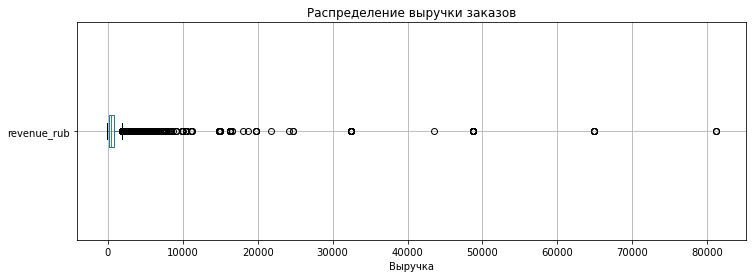

In [28]:
# Строим диаграмму размаха значений
plt.figure(figsize=(12, 4))

df.boxplot(column='revenue_rub', vert=False)

plt.title('Распределение выручки заказов')
plt.xlabel('Выручка')

# Выводим график
plt.show()

Распределение данных действительно правосторонее, однако характеризуется широким разбросом и «хвостами» в правой части диаграммы. Такие высокие значения можно отнести к выбросам. Высокие значения могут быть обусловлены реальной выручкой за билеты. Отрицательные значения выручки могут быть обусловлены возвратами билетов.
Чтобы посмотреть более типичную картину рассмотрим 99 перцентель и отфильтруем по нему.

In [29]:
p99 = df['revenue_rub'].quantile(0.99)
print(p99)

2628.419921875


In [30]:
df_filtred = df[df['revenue_rub'] <= p99]

Оценим статические показатели выручки после фильтрации.

In [31]:
df_filtred['revenue_rub'].describe()

count    287786.000000
mean        518.028076
std         511.974091
min         -90.760002
25%         111.849998
50%         343.849991
75%         788.659973
max        2628.419922
Name: revenue_rub, dtype: float64

Выбросы все равно присутствуют в данных, однако мы немного выровняли картину для анализа.
Построим диаграмму размаха после фильтрации.

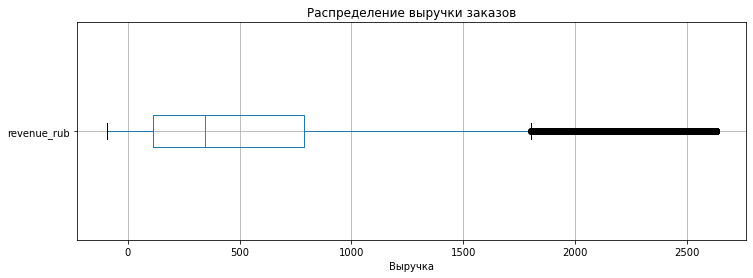

In [32]:
# Строим диаграмму размаха значений
plt.figure(figsize=(12, 4))

df_filtred.boxplot(column='revenue_rub', vert=False)

plt.title('Распределение выручки заказов')
plt.xlabel('Выручка')

# Выводим график
plt.show()

Оценим статические показатели количества купленных билетов после фильтрации.

In [33]:
df_filtred['tickets_count'].describe()

count    287786.000000
mean          2.740495
std           1.163073
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max          57.000000
Name: tickets_count, dtype: float64

Большинство заказов (75%) содержат от 1 до 3 билетов. Покупки от 4 билетов и выше встречаются реже, однако максимальное значение 57 билетов говорит о существовании групповых заказов, которые мы оставили в данных как важный сегмент для анализа лояльности.

Распределение скошено вправо, однако разброс не очень большой, судя по стандартному отклонению - 1.16.

Посмотрим 99 перцентель и построим диаграмму размаха.

In [34]:
pT99 = df_filtred['tickets_count'].quantile(0.99)
print(pT99)

6.0


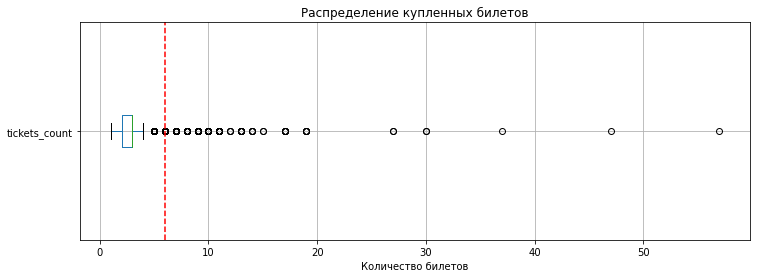

In [35]:
# Строим диаграмму размаха значений
plt.figure(figsize=(12, 4))

df_filtred.boxplot(column='tickets_count', vert=False)

plt.title('Распределение купленных билетов')
plt.xlabel('Количество билетов')
plt.axvline(x=pT99, color='red', linestyle='--')

# Выводим график
plt.show()

Максимальное значение составляет 57 билетов, что превышает 99-й перцентиль - 6 билетов. Однако, в отличие от выручки `revenue_rub`, где среднее значительно выше медианы из-за выбросов, для `tickets_count` среднее и медиана близки. Это говорит о том, что экстремальные значения (например, 57 билетов) не оказывают сильного влияния на общие статистики и могут соответствовать реальным групповым покупкам, поэтому фильтровать итоговый датафрейм не будем.

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


Фильтруем по id пользователя и по времени совершения заказа.

In [36]:
df_sorted = df_filtred.sort_values(by=['user_id', 'order_dt'])

Отбираем первичные значения для пользователя.

In [37]:
first_orders = df_sorted.groupby('user_id').first().reset_index()

Формируем профиль пользователя.

In [38]:
user_profile = df_sorted.groupby('user_id').agg(
    first_order_dt=('order_dt', 'min'),
    last_order_dt=('order_dt', 'max'),
    total_orders=('order_id', 'count'),
    avg_revenue_rub=('revenue_rub', 'mean'),
    avg_tickets_count=('tickets_count', 'mean'),
    avg_days_between=('days_since_prev', 'mean')
)

In [39]:
final_profile = user_profile.merge(
    first_orders[['user_id', 'device_type_canonical', 'region_name', 'service_name', 'event_type_main']],
    on='user_id',
    how='left'
)

Формируем два бинарных признака:

In [40]:
final_profile['is_two'] = final_profile['total_orders'] >= 2
final_profile['is_five'] = final_profile['total_orders'] >= 5

Проверим корректность сформированного профиля пользователя.

In [41]:
final_profile.head()

,user_id,first_order_dt,last_order_dt,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_between,device_type_canonical,region_name,service_name,event_type_main,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,1,1521.939941,4.000000,NaN,mobile,Каменевский регион,Край билетов,театр,False,False
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,2,774.010010,3.000000,75.0,mobile,Каменевский регион,Мой билет,выставки,True,False
2,000898990054619,2024-07-13,2024-10-23,3,767.213318,2.666667,51.0,mobile,Североярская область,Лови билет!,другое,True,False
3,00096d1f542ab2b,2024-08-15,2024-08-15,1,917.830017,4.000000,NaN,desktop,Каменевский регион,Край билетов,театр,False,False
4,000a55a418c128c,2024-09-29,2024-10-15,2,61.309998,1.500000,16.0,mobile,Поленовский край,Лучшие билеты,театр,True,False


In [42]:
final_profile['user_id'].is_unique

True

---
Профиль пользователя сформирован корректно. Все данные соответсвуют названию столбцов.

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [43]:
# Общее число пользователей
final_profile['user_id'].count()

21854

In [44]:
# Средняя выручка с одного заказа
round(df_filtred['revenue_rub'].mean(), 2)

518.03

In [45]:
# Доля пользователей, совершивших 2+ и 5+ заказов
for col in ['is_two', 'is_five']:
    print(round(final_profile[col].mean(), 2))

0.62
0.29


In [46]:
# Статические показатели
for col in ['total_orders', 'avg_tickets_count', 'avg_days_between']:
    print(f'Данные столбца: {col}')
    print(final_profile[col].describe())
    print()

Данные столбца: total_orders
count    21854.000000
mean        13.168573
std        121.674800
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max      10181.000000
Name: total_orders, dtype: float64

Данные столбца: avg_tickets_count
count    21854.000000
mean         2.743129
std          0.913080
min          1.000000
25%          2.000000
50%          2.750000
75%          3.076923
max         11.000000
Name: avg_tickets_count, dtype: float64

Данные столбца: avg_days_between
count    13521.000000
mean        15.836104
std         22.298199
min          0.000000
25%          1.000000
50%          8.000000
75%         20.400000
max        148.000000
Name: avg_days_between, dtype: float64



---
Можно предположить, что данные столбцов `total_orders` и `avg_days_between` имеют правостроннюю скошенность. Об этом говорит для `total_orders` значение среднего - 13.17 больше медианного значений - 2. Значение стандартного отклонения — 121.67, и при среднем 13.17 это указывает, что данные могут иметь большой разброс.
Для `avg_days_between` значение среднего - 15.84 больше медианного значений - 8. Значение стандартного отклонения — 22.3, и при среднем 15.84 это указывает, что данные могут иметь небольшой разброс.
`avg_tickets_count` значение среднего - 2.74 равняется медианному значению - 2.75. Значение стандартного отклонения почти ровняется 1 это указывает, что данные почти не имеют разброса.

Дополнительно посмотрим 95 и 99 перцентель для столбца `total_orders`.

In [47]:
final_profile['total_orders'].quantile(0.95)

31.349999999998545

In [48]:
p99_total = final_profile['total_orders'].quantile(0.99)
print(p99_total)

152.0


Проведем фильтрацию по 99 перцентелю, так как рассматриваем типичное поведение пользователей. Выбросы (суперактивные 1% пользователей) будут только мешать, потому что средние показатели станут нереалистично высокими.

In [49]:
final_profile_clean = final_profile[final_profile['total_orders'] <= p99_total].copy()
print(f"Осталось пользователей: {len(final_profile_clean)}")
print(f"Удалено: {len(final_profile) - len(final_profile_clean)} ({100*(1-len(final_profile_clean)/len(final_profile)):.1f}%)")

Осталось пользователей: 21638
Удалено: 216 (1.0%)


In [50]:
# Доля пользователей, совершивших 2+ и 5+ заказов после фильтрации
for col in ['is_two', 'is_five']:
    print(round(final_profile_clean[col].mean(), 2))

0.61
0.28


In [51]:
# Статические показатели после фильтрации
for col in ['total_orders', 'avg_tickets_count', 'avg_days_between']:
    print(f'Данные столбца: {col}')
    print(final_profile_clean[col].describe())
    print()

Данные столбца: total_orders
count    21638.000000
mean         6.501294
std         14.324031
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        152.000000
Name: total_orders, dtype: float64

Данные столбца: avg_tickets_count
count    21638.000000
mean         2.743319
std          0.917486
min          1.000000
25%          2.000000
50%          2.750000
75%          3.095238
max         11.000000
Name: avg_tickets_count, dtype: float64

Данные столбца: avg_days_between
count    13305.000000
mean        16.085749
std         22.391607
min          0.000000
25%          1.333333
50%          8.333333
75%         20.750000
max        148.000000
Name: avg_days_between, dtype: float64



---
Фильтрация пользователей по `total_orders` позволила устранить экстремальный выброс, не искажая основные распределения остальных признаков. Полученная выборка из 21 638 пользователей репрезентативна для анализа массового поведения: большинство пользователей совершают от 1 до 5 заказов, средний интервал между покупками – около 16 дней, среднее число билетов – 2.7. Дальнейший анализ можно проводить на этих данных.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [52]:
for col in ['event_type_main', 'device_type_canonical', 'region_name', 'service_name']:
    print(f'Пользователи сгруппированы по {col} \n\n{final_profile_clean[col].value_counts().sort_values(ascending=False)} \n')

Пользователи сгруппированы по event_type_main 

концерты    9561
другое      5431
театр       4225
стендап     1111
спорт        799
выставки     416
ёлки          95
Name: event_type_main, dtype: int64 

Пользователи сгруппированы по device_type_canonical 

mobile     17900
desktop     3738
Name: device_type_canonical, dtype: int64 

Пользователи сгруппированы по region_name 

Каменевский регион          7088
Североярская область        3765
Широковская область         1222
Озернинский край             677
Малиновоярский округ         526
                            ... 
Светолесский край              2
Тихогорская область            2
Сосноводолинская область       1
Яснопольский округ             1
Верхозёрский край              1
Name: region_name, Length: 81, dtype: int64 

Пользователи сгруппированы по service_name 

Билеты без проблем        5171
Мой билет                 2973
Лови билет!               2805
Билеты в руки             2565
Облачко                   2179
Весь в бил

In [53]:
for col in ['event_type_main', 'device_type_canonical', 'region_name', 'service_name']:
    print(f'Пользователи сгруппированы по {col} \n\n{final_profile_clean[col].value_counts(normalize=True).sort_values(ascending=False)} \n')

Пользователи сгруппированы по event_type_main 

концерты    0.441862
другое      0.250994
театр       0.195258
стендап     0.051345
спорт       0.036926
выставки    0.019225
ёлки        0.004390
Name: event_type_main, dtype: float64 

Пользователи сгруппированы по device_type_canonical 

mobile     0.827248
desktop    0.172752
Name: device_type_canonical, dtype: float64 

Пользователи сгруппированы по region_name 

Каменевский регион          0.327572
Североярская область        0.173999
Широковская область         0.056475
Озернинский край            0.031288
Малиновоярский округ        0.024309
                              ...   
Светолесский край           0.000092
Тихогорская область         0.000092
Сосноводолинская область    0.000046
Яснопольский округ          0.000046
Верхозёрский край           0.000046
Name: region_name, Length: 81, dtype: float64 

Пользователи сгруппированы по service_name 

Билеты без проблем        0.238978
Мой билет                 0.137397
Лови билет!

---
Распределение пользователей по сегментам неравномерное, есть ярко выраженные «точки входа» — сегменты, в которых сосредоточена основная масса пользователей.

**Тип мероприятия:**
- концерты – 44.2%
- другое – 25.1%
- театр – 19.5%

Вместе эти три сегмента охватывают почти 90% всех пользователей. Остальные (стендап, спорт, выставки, ёлки) составляют менее 10%.

**Тип устройства:**
- mobile – 82.7%
- desktop – 17.3%

**Регион:**
- Каменевский регион – 32.8%
- Североярская область – 17.4%
- Широковская область – 5.6%

Топ‑3 региона охватывают более 55% пользователей. Остальные 78 регионов имеют долю менее 5%.

**Билетный оператор:**
- Билеты без проблем – 23.9%
- Мой билет – 13.7%
- Лови билет! – 13.0%
- Билеты в руки – 11.9%
- Облачко – 10.1%

Топ‑5 операторов охватывают более 72% пользователей. Остальные операторы имеют значительно меньшую долю.

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [54]:
# Доля вернувшихся пользователей
for col in ['event_type_main', 'device_type_canonical', 'region_name', 'service_name']:
    print(f'Доля пользователей по {col}')
    print(final_profile_clean.groupby(col)['is_two'].mean().sort_values(ascending=False).head(10))
    print()

Доля пользователей по event_type_main
event_type_main
выставки    0.641827
театр       0.632663
концерты    0.618345
стендап     0.609361
другое      0.596575
спорт       0.560701
ёлки        0.557895
Name: is_two, dtype: float64

Доля пользователей по device_type_canonical
device_type_canonical
desktop    0.640449
mobile     0.607598
Name: is_two, dtype: float64

Доля пользователей по region_name
region_name
Верхозёрский край         1.000000
Озернопольская область    0.896552
Радужнопольский край      0.791667
Лесостепной край          0.716667
Тихолесский край          0.700000
Горноземский регион       0.689655
Ягодиновская область      0.671875
Шанырский регион          0.670683
Верховинская область      0.666667
Лесноярский край          0.666667
Name: is_two, dtype: float64

Доля пользователей по service_name
service_name
Зе Бест!             1.000000
Быстрый кассир       0.854839
Билет по телефону    0.833333
Реестр               0.812500
Crazy ticket!        0.708333
Восьмёрка

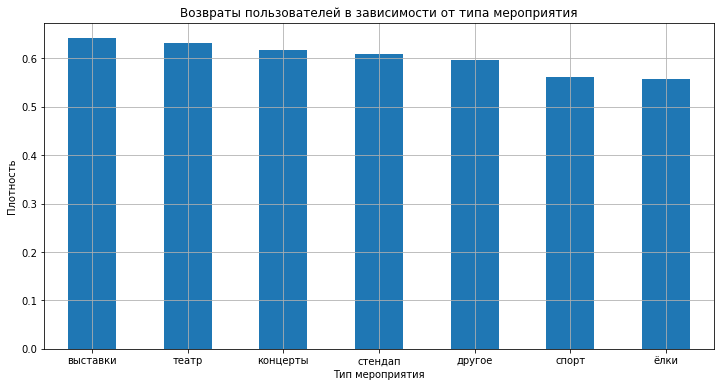

In [55]:
# Строим столбчатую диаграмму
plt.figure(figsize=(12, 6))

f = final_profile_clean.groupby('event_type_main')['is_two'].mean().sort_values(ascending=False)
f.plot(
    kind='bar', 
    rot=0, 
    legend=False, 
    title=f'Возвраты пользователей в зависимости от типа мероприятия'
)

plt.xlabel('Тип мероприятия')
plt.ylabel('Плотность')

plt.grid()

# Выводим график
plt.show()

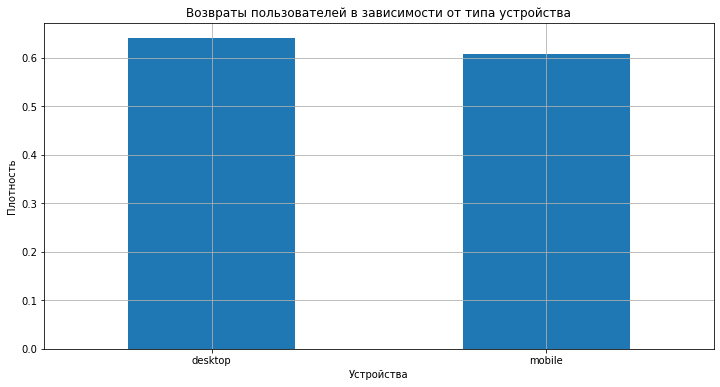

In [56]:
# Строим столбчатую диаграмму
plt.figure(figsize=(12, 6))

f = final_profile_clean.groupby('device_type_canonical')['is_two'].mean().sort_values(ascending=False)
f.plot(
    kind='bar', 
    rot=0, 
    legend=False, 
    title=f'Возвраты пользователей в зависимости от типа устройства'
)

plt.xlabel('Устройства')
plt.ylabel('Плотность')

plt.grid()

# Выводим график
plt.show()

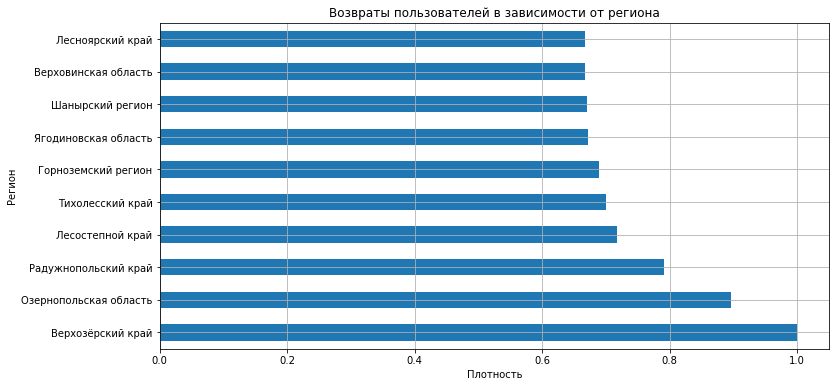

In [57]:
# Строим столбчатую диаграмму
plt.figure(figsize=(12, 6))

f = final_profile_clean.groupby('region_name')['is_two'].mean().sort_values(ascending=False).head(10)
f.plot(
    kind='barh', 
    rot=0, 
    legend=False, 
    title=f'Возвраты пользователей в зависимости от региона'
)

plt.xlabel('Плотность')
plt.ylabel('Регион')

plt.grid()

# Выводим график
plt.show()

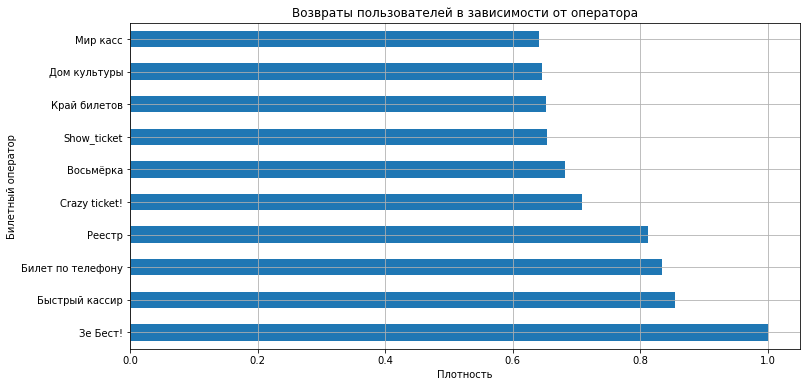

In [58]:
# Строим столбчатую диаграмму
plt.figure(figsize=(12, 6))

f = final_profile_clean.groupby('service_name')['is_two'].mean().sort_values(ascending=False).head(10)
f.plot(
    kind='barh', 
    rot=0, 
    legend=False, 
    title=f'Возвраты пользователей в зависимости от оператора'
)

plt.xlabel('Плотность')
plt.ylabel('Билетный оператор')

plt.grid()

# Выводим график
plt.show()

---
**Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?**

- По типу мероприятия: Чаще возвращаются пользователи, первый заказ которых был на `выставки` - 64.1% и `театр` - 63.4%. Оба сегмента достаточно велики.

- По типу устройства: Пользователи, оформляющие первый заказ с `desktop`, возвращаются чаще - 63.9%, чем с `mobile` - 60.8%. Разница небольшая, но устойчивая.

- По региону: Пользователи из таких регионов, как: `Верхозёрский край` - 100%, `Озернопольская область` - 90%, `Радужнопольский край` - 79% - возвращаются часто.

- По билетному оператору: Пользователи чаще всего возвращаются, когда использовали следующие операторы: `Зе Бест!` - 100%, `Быстрый кассир` - 85%, `Реестр` - 81%. Другими пользуются меньше 80%.

**Наблюдаются ли успешные «точки входа»?**

Да, наблюдаются.
Сегменты с долей повторных заказов выше средней `final_profile_clean['is_two'].mean()` - 61%:
- выставки (64.1%) — отличная точка входа.
- театр (63.4%) — тоже выше среднего.
- desktop (63.9%) — можно рассматривать как успешный канал первого заказа.

Эти сегменты стоит использовать для персонализированных предложений и таргетинга.

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

**Гипотеза 1**

- Доля повтора у спорта: 56.4%
- Доля повтора у концертов: 61.8%

**Вывод:** Гипотеза не подтверждается. На самом деле спорт даёт меньшую вероятность возврата, чем концерты. Разница составляет около 5.4 процентных пункта.

---
Проверим гипотезу 2.

In [59]:
# Топ-3 региона по численности
top_regions = final_profile_clean['region_name'].value_counts().head(3).index
active_share = final_profile_clean[final_profile_clean['region_name'].isin(top_regions)]['is_two'].mean()

print(f'Активные регионы: доля повтора = {active_share:.2f}')

Активные регионы: доля повтора = 0.63


In [60]:
# Регионы с числом пользователей от 30 до 100 (исключая очень мелкие)
region_counts = final_profile_clean['region_name'].value_counts()
mid_regions = region_counts[(region_counts >= 30) & (region_counts <= 100)].index
low_share = final_profile_clean[final_profile_clean['region_name'].isin(mid_regions)]['is_two'].mean()
print(f'Менее активные регионы: доля повтора = {low_share:.2f}')

Менее активные регионы: доля повтора = 0.55


---
**Гипотеза 2.**

Гипотеза подтверждается. В активных регионах (топ-3 по числу пользователей) доля повторных заказов составляет 63%, а в менее активных регионах (30–100 пользователей) — 55%. Разница значимая.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


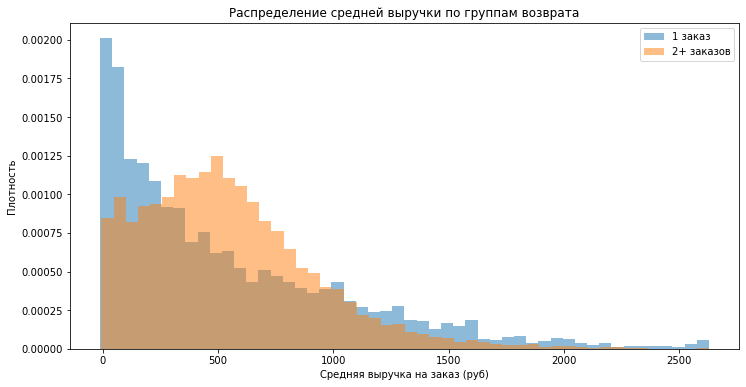

In [61]:
plt.figure(figsize=(12, 6))

for i in final_profile_clean['is_two'].unique():
    final_profile_clean.loc[final_profile_clean['is_two'] == i, 'avg_revenue_rub'].plot(
        kind='hist',
        density=True,
        bins=50,
        alpha=0.5,
        label= f'{"1 заказ" if not i else "2+ заказов"}',
        legend=True
    )

plt.title(f'Распределение средней выручки по группам возврата')
plt.xlabel('Средняя выручка на заказ (руб)')
plt.ylabel('Плотность')
plt.legend()

# Выводим график
plt.show()

---
Средняя выручка для 1 заказа находится в диапазоне от 0 до 300 руб., а для 2+ заказов - 300-600 руб.

По графику прослеживается разница между группами - для 2+ заказов пик смещен правее относительно пика за 1 заказ. При этом пиковое значение плотности у 1 заказа превышает пиковое значение для 2+ заказов.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [62]:
group_2_4 = final_profile_clean[(final_profile_clean['is_two']) & (~final_profile_clean['is_five'])]['avg_revenue_rub']
group_5_plus = final_profile_clean[final_profile_clean['is_five']]['avg_revenue_rub']

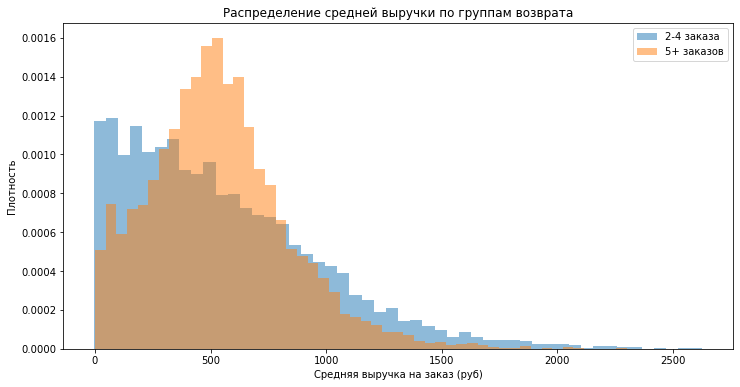

In [63]:
plt.figure(figsize=(12,6))
plt.hist(group_2_4, bins=50, alpha=0.5, label='2-4 заказа', density=True)
plt.hist(group_5_plus, bins=50, alpha=0.5, label='5+ заказов', density=True)
plt.xlabel('Средняя выручка на заказ (руб)')
plt.ylabel('Плотность')
plt.legend()
plt.title('Распределение средней выручки по группам возврата')
# plt.xlim(0, 5000)  # раскомментируйте, если график слишком широкий
plt.show()

---
Распределение средней выручки у пользователей с 2–4 заказами практически не отличается от распределения у пользователей с 1 заказом. Однако пользователи с 5+ заказами демонстрируют более высокую среднюю выручку (пик в диапазоне 500–800 руб). Это говорит о том, что сверхлояльные клиенты не только часто возвращаются, но и тратят больше за один раз.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

In [64]:
final_profile_clean['avg_tickets_count'].describe()

count    21638.000000
mean         2.743319
std          0.917486
min          1.000000
25%          2.000000
50%          2.750000
75%          3.095238
max         11.000000
Name: avg_tickets_count, dtype: float64

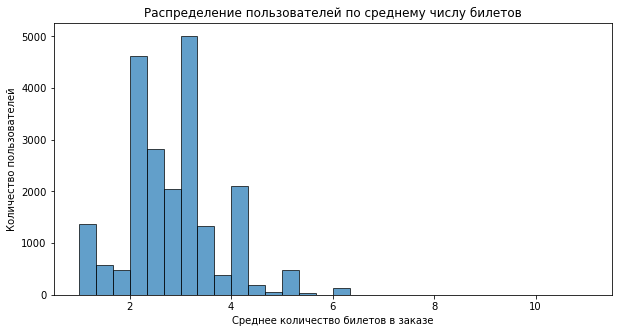

In [65]:
plt.figure(figsize=(10, 5))
plt.hist(final_profile_clean['avg_tickets_count'], bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Среднее количество билетов в заказе')
plt.ylabel('Количество пользователей')
plt.title('Распределение пользователей по среднему числу билетов')
plt.show()

---
**Промежуточный вывод**
Основная масса пользователей (около 75%) покупает в среднем 1–3 билета за заказ. Значения выше 5 билетов встречаются редко (вероятно, менее 5% пользователей), поэтому распределение можно считать сконцентрированным в низком диапазоне. 

In [66]:
# Распределим по сегментам
def ticket_segment(row):
    if row['avg_tickets_count'] < 2:
        return '1-2 билета'
    elif row['avg_tickets_count'] < 3:
        return '2-3 билета'
    elif row['avg_tickets_count'] < 5:
        return '3-5 билетов'
    else:
        return '5+ билетов'
    
final_profile_clean['ticket_segment'] = final_profile_clean.apply(ticket_segment, axis=1)

In [67]:
# Считаем общее число пользователей и долю вернувшихся пользователей.
final_profile_clean.groupby('ticket_segment').agg({
    'user_id': 'count',
    'is_two':'mean'
}).reset_index()

,ticket_segment,user_id,is_two
0,1-2 билета,2419,0.513022
1,2-3 билета,9498,0.735839
2,3-5 билетов,9060,0.542605
3,5+ билетов,661,0.187595


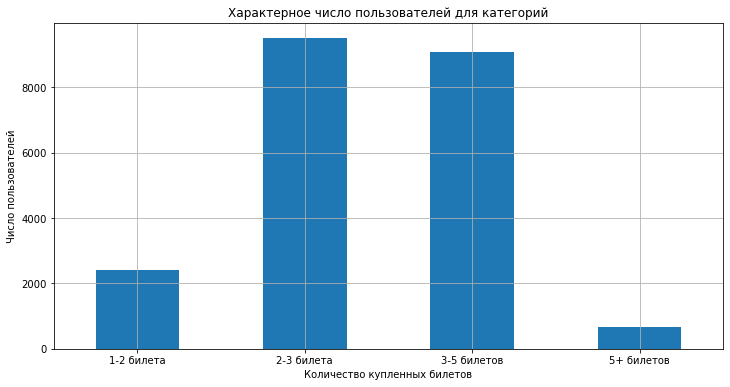

In [68]:
plt.figure(figsize=(12, 6))

grouped = final_profile_clean.groupby('ticket_segment')['user_id'].count()
grouped.plot(
               kind='bar',
               rot=0,
               legend=False,
               title=f'Характерное число пользователей для категорий'
)

plt.xlabel('Количество купленных билетов')
plt.ylabel('Число пользователей')

plt.grid()

# Выводим график
plt.show()

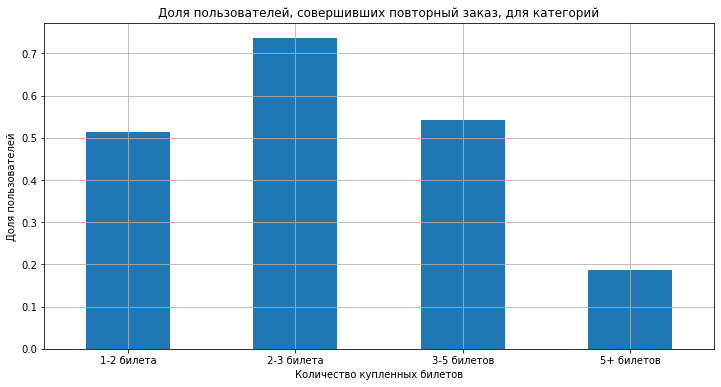

In [69]:
plt.figure(figsize=(12, 6))

grouped1 = final_profile_clean.groupby('ticket_segment')['is_two'].mean()
grouped1.plot(
               kind='bar',
               rot=0,
               legend=False,
               title=f'Доля пользователей, совершивших повторный заказ, для категорий'
)

plt.xlabel('Количество купленных билетов')
plt.ylabel('Доля пользователей')

plt.grid()

# Выводим график
plt.show()

---
Распределение пользователей сильно сконцентрировано:

- «2–3 билета» охватывает 9498 пользователей.
- «3–5 билетов» — 9060 пользователей.

- «1–2 билета» — 2419 пользователей.
- «5+ билетов» — всего 661 пользователь.

Таким образом, подавляющее большинство пользователей покупает в среднем от 2 до 5 билетов за заказ. Сегменты с крайними значениями (очень мало или очень много билетов) малочисленны.

---
В данных присутствуют сегменты с аномально высокой или низкой долей повторных покупок:

- Аномально высокая доля повторных заказов — в сегменте «2–3 билета» - 73.6%.
- Аномально низкая доля — в сегменте «5+ билетов» - 18.8%. Это намного ниже средней.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [70]:
final_profile_clean['weekday'] = final_profile_clean['first_order_dt'].dt.day_name()

In [71]:
final_profile_clean.groupby('weekday').agg({
    'user_id':'count',
    'is_two':'mean'
}).reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

,user_id,is_two
weekday,,
Monday,2930,0.630375
Tuesday,3176,0.619018
Wednesday,3057,0.621851
Thursday,3113,0.594282
Friday,3259,0.598343
Saturday,3326,0.628082
Sunday,2777,0.600288


In [72]:
correct_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

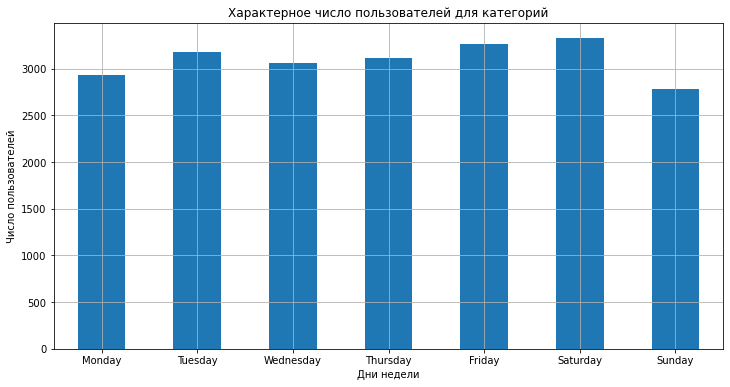

In [73]:
plt.figure(figsize=(12, 6))

weekday_count = final_profile_clean.groupby('weekday')['user_id'].count()
weekday_count = weekday_count.reindex(correct_order)
weekday_count.plot(
               kind='bar',
               rot=0,
               legend=False,
               title=f'Характерное число пользователей для категорий'
)

plt.xlabel('Дни недели')
plt.ylabel('Число пользователей')

plt.grid()

# Выводим график
plt.show()

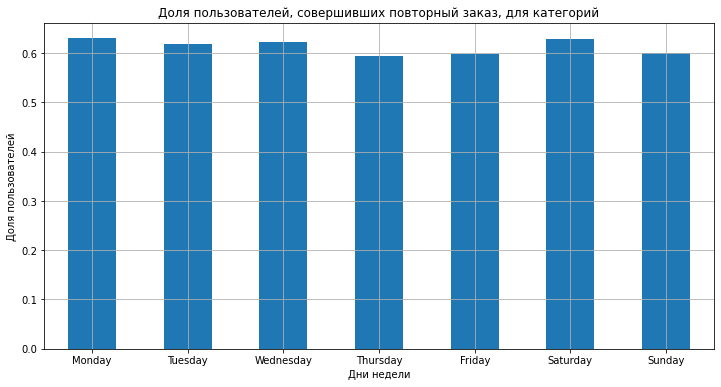

In [74]:
plt.figure(figsize=(12, 6))

weekday_repeat = final_profile_clean.groupby('weekday')['is_two'].mean()
weekday_repeat = weekday_repeat.reindex(correct_order)
weekday_repeat.plot(
               kind='bar',
               rot=0,
               legend=False,
               title=f'Доля пользователей, совершивших повторный заказ, для категорий'
)

plt.xlabel('Дни недели')
plt.ylabel('Доля пользователей')

plt.grid()

# Выводим график
plt.show()

---
Количество пользователей и доля вернувшихся пользователей не зависит от того, в какой день недели совершили свой первый заказ пользователи.
Количество пользователей в среднем на каждый день недели приходится - 3000, а доля вернувшихся пользователей - 60%.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---

In [75]:
group_2_4 = final_profile_clean[(final_profile_clean['is_two']) & (~final_profile_clean['is_five'])]['avg_days_between']
group_5_plus = final_profile_clean[final_profile_clean['is_five']]['avg_days_between']

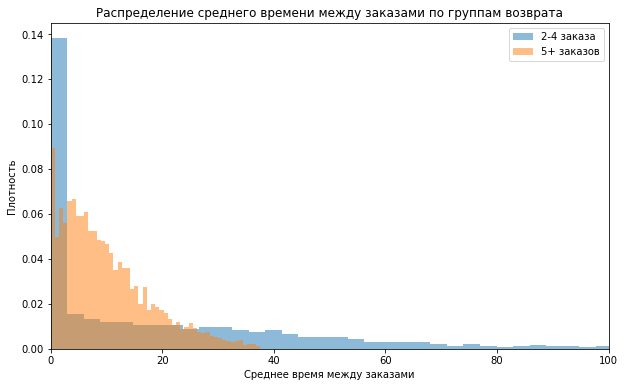

In [76]:
plt.figure(figsize=(10,6))
plt.hist(group_2_4, bins=50, alpha=0.5, label='2-4 заказа', density=True)
plt.hist(group_5_plus, bins=50, alpha=0.5, label='5+ заказов', density=True)
plt.xlabel('Среднее время между заказами')
plt.ylabel('Плотность')
plt.legend()
plt.title('Распределение среднего времени между заказами по группам возврата')
plt.xlim(0, 100)
plt.show()

Распределения существенно различаются:
- У пользователей с 5+ заказами пик плотности находится в области 0–5 дней, и вся основная масса сконцентрирована в интервале 0–20 дней.
- У пользователей с 2–4 заказами пик также смещён влево, но он менее высокий, и распределение более растянуто вправо (до 100 дней и более).


Чем чаще пользователь возвращается, тем выше вероятность, что он совершит 5 и более заказов. А те, кто делает заказы реже, с большей вероятностью останавливаются на 2–4 покупках.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [79]:
!pip install phik
!pip install scipy
from phik import phik_matrix

ModuleNotFoundError: No module named 'scipy.stats._mvn'

In [ ]:
condition1 = ~final_profile_clean['is_two']
condition2 = (final_profile_clean['is_two']) & (~final_profile_clean['is_five'])
condition3 = final_profile_clean['is_five']

In [ ]:
interval_cols = ['total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between']
# Вычисляем корреляционную матрицу
correlation_matrix = final_profile_clean[['total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between',
             'event_type_main', 'device_type_canonical', 'region_name', 'service_name', 'weekday']].phik_matrix(interval_cols=interval_cols)

# Выводим результат
print('Корреляционная матрица с коэффициентом phi_k для переменной rating')
correlation_matrix.loc[correlation_matrix.index != 'total_orders'][['total_orders']].sort_values(by='total_orders', ascending=False)

In [ ]:
# Строим тепловую карту
plt.figure(figsize=(2, 6))

# Сохраняем матрицу корреляции признака total_orders с другими признаками клиента
data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'total_orders'][['total_orders']].sort_values(by='total_orders', ascending=False)
sns.heatmap(data_heatmap,
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.2f', # Форматируем значения корреляции: два знака после точки
            cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5, # Форматируем линию между ячейками карты
            cbar=False # Отключаем цветовую шкалу
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n для данных total_orders')
plt.xlabel('Число заказов')

# Выводим график
plt.show() 

---
Для всех пользователей коэффициенты phi_k показали, что наибольшая связь с количеством заказов `total_orders` наблюдается у признака `avg_days_between` (0.284), затем у `avg_tickets_count` (0.226) и `avg_revenue_rub` (0.219). Связь категориальных признаков слабая (<0.12). Полученные значения близки к нулю, проверим разброс данных `total_orders`.

---

In [ ]:
final_profile_clean['total_orders'].value_counts(normalize=True).head(10)

---
Распределение `total_orders` показывает, что максимальная доля пользователей с одним заказом составляет 38.7%, доли пользователей с 2 и 3 заказами не превышают 10%, а остальные значения (от 4 до 151) встречаются реже. Это означает, что в данных нет единственного доминирующего значения, а присутствует достаточная вариация для корректного вычисления коэффициентов корреляции. Таким образом, полученные коэффициенты phi_k (0.284 для `avg_days_between`, 0.226 для `avg_tickets_count` и 0.219 для `avg_revenue_rub`) являются осмысленными и отражают реальные связи с числом заказов.

---

In [ ]:
interval_cols = ['total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between']
correlation_matrix1 = final_profile_clean[condition1][['total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between',
             'event_type_main', 'device_type_canonical', 'region_name', 'service_name', 'weekday']].phik_matrix(interval_cols=interval_cols)

print('Корреляционная матрица (сегмент: 1 заказ)')
if 'total_orders' in correlation_matrix1.columns:
    print(correlation_matrix1.loc[correlation_matrix1.index != 'total_orders'][['total_orders']].sort_values(by='total_orders', ascending=False))
else:
    print("Столбец 'total_orders' отсутствует в матрице (нет вариации) – корреляция не определена.")

In [ ]:
interval_cols = ['total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between']
correlation_matrix2_4 = final_profile_clean[condition2][['total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between',
             'event_type_main', 'device_type_canonical', 'region_name', 'service_name', 'weekday']].phik_matrix(interval_cols=interval_cols)

print('Корреляционная матрица (сегмент: 2–4 заказа)')
correlation_matrix2_4.loc[correlation_matrix2_4.index != 'total_orders'][['total_orders']].sort_values(by='total_orders', ascending=False)

In [ ]:
interval_cols = ['total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between']
correlation_matrix5 = final_profile_clean[condition3][['total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between',
             'event_type_main', 'device_type_canonical', 'region_name', 'service_name', 'weekday']].phik_matrix(interval_cols=interval_cols)

print('Корреляционная матрица (сегмент: 5+ заказов)')
correlation_matrix5.loc[correlation_matrix5.index != 'total_orders'][['total_orders']].sort_values(by='total_orders', ascending=False)

In [ ]:
# Строим тепловую карту
plt.figure(figsize=(2, 6))

# Сохраняем матрицу корреляции признака total_orders с другими признаками клиента
data_heatmap = correlation_matrix2_4.loc[correlation_matrix2_4.index != 'total_orders'][['total_orders']].sort_values(by='total_orders', ascending=False)
sns.heatmap(data_heatmap,
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.2f', # Форматируем значения корреляции: два знака после точки
            cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5, # Форматируем линию между ячейками карты
            cbar=False # Отключаем цветовую шкалу
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n для данных total_orders')
plt.xlabel('Число заказов')

# Выводим график
plt.show() 

In [ ]:
# Строим тепловую карту
plt.figure(figsize=(2, 6))

# Сохраняем матрицу корреляции признака total_orders с другими признаками клиента
data_heatmap = correlation_matrix5.loc[correlation_matrix5.index != 'total_orders'][['total_orders']].sort_values(by='total_orders', ascending=False)
sns.heatmap(data_heatmap,
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.2f', # Форматируем значения корреляции: два знака после точки
            cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5, # Форматируем линию между ячейками карты
            cbar=False # Отключаем цветовую шкалу
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n для данных total_orders')
plt.xlabel('Число заказов')

# Выводим график
plt.show() 

---
**Анализ корреляции внутри сегментов**

- Для пользователей с 1 заказом корреляция не рассчитывалась из-за отсутствия вариации `total_orders`.

- В сегменте 2–4 заказа наибольшая связь наблюдается с `avg_days_between` - 0.385 и `avg_tickets_count` - 0.369 – умеренная. Это означает, что среди вернувшихся клиентов те, кто покупает больше билетов и возвращается чаще, склонны делать больше заказов (до 4).

- В сегменте 5+ заказов связь с `avg_days_between` становится сильной - 0.695 , а с другими признаками – слабой. Это говорит, что среди сверхактивных пользователей именно частота возвратов (короткий интервал) наиболее сильно связана с общим числом заказов.

---

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

---
Проанализирована выгрузка заказов Яндекс Афиши за 2024 год из базы данных SQL. После приведения валюты (тенге → рубли), удаления выбросов по выручке и устранения аномального пользователя с 10 тыс. заказов в выборку вошло 21 638 пользователей и 287 786 заказов.

**Портрет типичного клиента**

Большинство пользователей приходят с мобильных устройств - 83%, покупают 2–3 билета и тратят около 350–550 руб на заказ. Однако самые ценные клиенты – те, кто покупает ровно 2–3 билета за раз: они возвращаются почти в 3/4 случаев. Парадокс: покупатели 5+ билетов (сегмента) почти не возвращаются – возможно, это разовые организаторы или подарки, и удерживать их бессмысленно.

**Главный двигатель лояльности – частота, а не чек**

Клиенты, которые делают следующую покупку в течение 10 дней, с высокой вероятностью становятся «суперклиентами» (5+ заказов). Средний чек влияет слабо, зато интервал между заказами – ключевой предсказатель. Вывод: маркетинг должен быть нацелен на быстрое возвращение, а не на наращивание чека любой ценой.

**Гипотеза о спорте оказалась мифом**

Ожидалось, что фанаты спорта лояльнее, но данные показывают обратное: спорт даёт 56% возврата – ниже возврата с концертов - 62%. Возможно, спортивные мероприятия покупают в подарок или разово. Рекомендация: не тратить бюджет на удержание спортивной аудитории, пока не тестировать специальные абонементы.

**Региональных «золотых» точек входа нет**

В крупных регионах доля повтора около 62–63%. Мелкие регионы с 100% возврата – это статистический шум (1–2 человека). Значит, региональная сегментация не даст выигрыша.

**День недели не имеет значения**

Первый заказ в любой из дней недели – возврат одинаков. Не нужно настраивать рекламу по дням недели.

---
**Рекомендации**

Главный рычаг – скорость возврата: сокращение интервала между заказами с 20–40 дней до 5–10 дней может перевести клиента из группы «2–4 заказа» в «5+».

Чтобы сократить интервал можно сделать:
- напоминания через 3–7 дней после покупки с сообщением: «вам может понравиться это мероприятие».
- персональные скидки на следующие билеты при быстром возврате.

Золотой сегмент – 2–3 билета:

Стоит давать предложения «купи ещё один билет – получи скидку на следующее посещение». Это повысит и частоту, и чек.


На что стоит обратить внимание:

- Удержание покупателей 5+ билетов – они одноразовые. Возможно, подобным клиентам стоит предлагать скидку на покупку билетов: чем больше купили билетов за раз, тем больше скидка - так можно увеличить возвращаемость клиентов.
- Спортивные мероприятия как первая покупка – низкая повторная активность, возможно стоит сосредоточиться на клиентах, которые покупают билеты на концерты. Или тестировать специальные акции (абонементы, скидки на повторные посещения).
- Мобильные пользователи возвращаются хуже, возможно, им нужно улучшить приложение.

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.